# Figure: Cross-species motif generalization (held-out taxa)

This figure tests whether the regulatory grammar learned by **Shorkie_LM** generalizes across evolutionary distance. The LM is run on species that were *held out of LM training*, per-base contribution scores are summarized with TF-MoDISco, and the discovered motif logos are visualized for five taxonomic tiers ordered by increasing distance from the *Saccharomycetales* the model trained on: `saccharomycetales_select` (held-out *Saccharomycetales*), `strains_select` (held-out *S. cerevisiae* strains), `schizosaccharomycetales` (fission yeasts), `orbiliales` (early-diverging Ascomycota), and `ascomycota` (broad Ascomycota). Each panel shows the top discovered motif (per-position-IC-weighted contribution-score logo) for one tier; recovering canonical DNA-binding motifs even in distant clades indicates the LM has captured transferable sequence grammar.

**Reproduces:** the cross-species motif-logo panel across the 5 unseen taxonomic tiers.

**Upstream:** `scripts/04_analysis/shorkie_lm/motif_analysis/motif_lm__unseen_species/` — for each tier run `1_search_motif.py` (extract per-base LM contribution scores) -> `2_modisco_script.sh` (TF-MoDISco) -> `3_modisco_report.sh` (annotate). This writes each tier's `{tier}_viz_seq/unet_small_bert_drop/modisco_results_w_16384_n_1000000.h5`, which this notebook loads. These intermediates are work-dir-only and are not part of the released data manifest, so this notebook is **not** runnable end-to-end from released data.

**Requires:** the `yeast_ml` conda env with this repo installed (`pip install -e .`) and `logomaker`. No GPU needed (LM contribution scores are precomputed upstream; this is a CPU plotting step).

**Source script:** ported from `scripts/04_analysis/shorkie_lm/motif_analysis/motif_lm__unseen_species/4_viz_motif.py` (logo rendering) with tier enumeration following `3_motif_cluster/1_motif_cluster.py`.

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import logomaker

# shorkie package (path resolution only)
from shorkie import config

## Path resolution

`results.modisco_lm` points at the in-distribution motif-LM viz dir (`.../motif_LM/saccharomycetales_viz_seq`). The unseen-species tiers live in a sibling tree, `.../motif_LM__unseen_species/{tier}_viz_seq/unet_small_bert_drop/`. We derive that base from the released config key (going one level up to `experiments_root/motif_LM__unseen_species`) and reference each tier's per-tier subdir below — never a hardcoded absolute path.

In [2]:
# Base dir for the unseen-species motif sweep (results.modisco_unseen =
# .../experiments/motif_LM__unseen_species); each tier has its own subdir.
unseen_root = config.path("results.modisco_unseen")

MODEL_ARCH = "unet_small_bert_drop"
MODISCO_FNAME = "modisco_results_w_16384_n_1000000.h5"

# Five held-out taxonomic tiers, ordered by increasing distance from the
# Saccharomycetales the LM was trained on.
TIERS = [
    ("saccharomycetales_select", "Held-out Saccharomycetales"),
    ("strains_select",           "Held-out S. cerevisiae strains"),
    ("schizosaccharomycetales",  "Schizosaccharomycetales (fission yeasts)"),
    ("orbiliales",               "Orbiliales (early-diverging Ascomycota)"),
    ("ascomycota",               "Ascomycota (broad)"),
]

def tier_h5(tier):
    """Per-tier TF-MoDISco results .h5 produced by the upstream unseen-species stage."""
    return unseen_root / f"{tier}_viz_seq" / MODEL_ARCH / MODISCO_FNAME

for tier, _ in TIERS:
    p = tier_h5(tier)
    print(f"{tier:28s} {'OK ' if p.is_file() else 'MISSING '} {p}")

saccharomycetales_select     OK  /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/motif_LM__unseen_species/saccharomycetales_select_viz_seq/unet_small_bert_drop/modisco_results_w_16384_n_1000000.h5
strains_select               OK  /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/motif_LM__unseen_species/strains_select_viz_seq/unet_small_bert_drop/modisco_results_w_16384_n_1000000.h5
schizosaccharomycetales      OK  /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/motif_LM__unseen_species/schizosaccharomycetales_viz_seq/unet_small_bert_drop/modisco_results_w_16384_n_1000000.h5
orbiliales                   OK  /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/motif_LM__unseen_species/orbiliales_viz_seq/unet_small_bert_drop/modisco_results_w_16384_n_1000000.h5
ascomycota                   OK  /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/motif_LM__unseen_species/ascomycota_viz_seq/unet_small_bert_drop/modisco_results_w_16384_n_1000000.h5


## Logo helpers (ported from `4_viz_motif.py`)

The source script renders contribution-weight-matrix (CWM) logos with `logomaker`, scaling each position's letter heights by its information content. We port `compute_per_position_ic` and the logo-drawing routine verbatim (no shorkie helper exists for sequence-logo rendering, so this stays inline). The contribution scores are read from each MoDISco pattern's `contrib_scores` dataset under `pos_patterns` / `neg_patterns`, exactly as the source script does.

In [3]:
def compute_per_position_ic(ppm, background, pseudocount):
    """Per-position information content (bits) of a position-probability matrix."""
    alphabet_len = len(background)
    ic = ((np.log((ppm + pseudocount) / (1 + pseudocount * alphabet_len)) / np.log(2)) * ppm
          - (np.log(background) * background / np.log(2))[None, :])
    return np.sum(ic, axis=1)


def draw_logo(array, ax, title):
    """Draw a sequence logo (A/C/G/T columns) on the given axis (ported from _plot_weights)."""
    df = pd.DataFrame(array, columns=["A", "C", "G", "T"])
    df.index.name = "pos"
    logo = logomaker.Logo(df, ax=ax)
    logo.style_spines(visible=False)
    ax.set_ylim(min(df.sum(axis=1).min(), 0), df.sum(axis=1).max())
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=10)


def top_pattern_cwm(h5_path, trim_threshold=0.3):
    """Return the IC-trimmed forward CWM of the highest-seqlet-count motif in an .h5.

    Mirrors 4_viz_motif.py: read contrib_scores per pattern, pick the strongest one,
    and trim flanks to the high-contribution core (with a 4 bp pad).
    """
    best = None  # (n_seqlets, cwm_fwd)
    with h5py.File(h5_path, "r") as f:
        for group_name in ("pos_patterns", "neg_patterns"):
            if group_name not in f:
                continue
            for pattern_name, pattern in f[group_name].items():
                cwm_fwd = np.array(pattern["contrib_scores"][:])
                n_seqlets = pattern["seqlets"]["start"].shape[0] if "seqlets" in pattern else cwm_fwd.shape[0]
                if best is None or n_seqlets > best[0]:
                    best = (n_seqlets, cwm_fwd)
    if best is None:
        return None
    cwm_fwd = best[1]
    score = np.sum(np.abs(cwm_fwd), axis=1)
    pass_inds = np.where(score >= np.max(score) * trim_threshold)[0]
    start = max(np.min(pass_inds) - 4, 0)
    end = min(np.max(pass_inds) + 4 + 1, len(score))
    return cwm_fwd[start:end]

## Figure: top motif logo per taxonomic tier

One row per held-out tier; each panel shows the strongest discovered motif's IC-weighted contribution logo. Tiers whose upstream `.h5` has not been produced are left blank with a note.

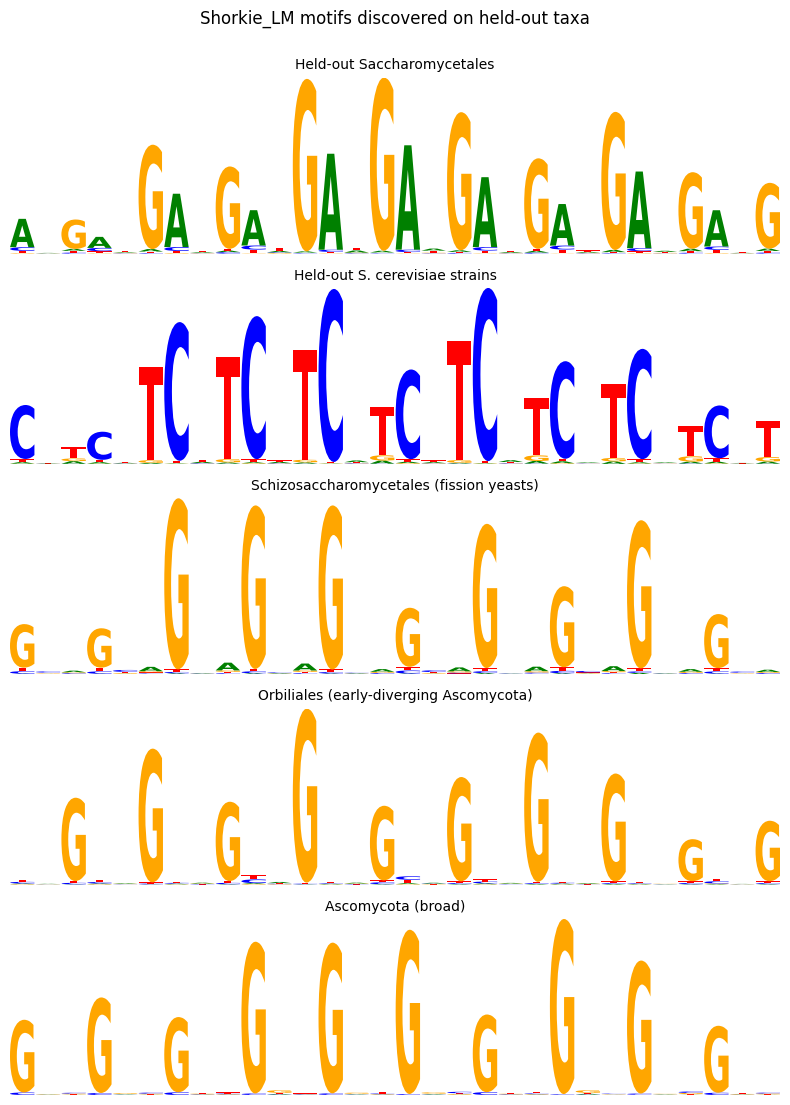

In [4]:
background = np.array([0.25, 0.25, 0.25, 0.25])

fig, axes = plt.subplots(len(TIERS), 1, figsize=(8, 2.2 * len(TIERS)))
if len(TIERS) == 1:
    axes = [axes]

for ax, (tier, label) in zip(axes, TIERS):
    h5_path = tier_h5(tier)
    if not h5_path.is_file():
        ax.text(0.5, 0.5, f"{label}\n(upstream modisco .h5 not found)",
                ha="center", va="center", transform=ax.transAxes, fontsize=9, color="0.5")
        ax.set_axis_off()
        continue
    cwm = top_pattern_cwm(h5_path)
    if cwm is None:
        ax.text(0.5, 0.5, f"{label}\n(no motifs in .h5)",
                ha="center", va="center", transform=ax.transAxes, fontsize=9, color="0.5")
        ax.set_axis_off()
        continue
    # IC-weight the (already contribution-scored) CWM, as in 4_viz_motif.py's make_logo path.
    ppm = np.clip(cwm, 0, None)
    row_sums = ppm.sum(axis=1, keepdims=True)
    ppm = np.divide(ppm, row_sums, out=np.full_like(ppm, 0.25), where=row_sums > 0)
    ic = compute_per_position_ic(ppm, background, 0.001)
    draw_logo(cwm * ic[:, None], ax, label)

fig.suptitle("Shorkie_LM motifs discovered on held-out taxa", fontsize=12, y=1.0)
fig.tight_layout()
plt.show()

**Interpretation.** Reading top to bottom, the panels span increasing evolutionary distance from the training clade. Crisp, high-information logos in the nearer tiers (`saccharomycetales_select`, `strains_select`) and persistence of recognizable motif structure into the distant tiers (`schizosaccharomycetales`, `orbiliales`, `ascomycota`) is the evidence that Shorkie_LM's learned regulatory grammar generalizes beyond the species it was trained on. To regenerate the underlying `.h5` for any tier, run the unseen-species modisco stage in `scripts/04_analysis/shorkie_lm/motif_analysis/motif_lm__unseen_species/` (`1_search_motif.py` -> `2_modisco_script.sh` -> `3_modisco_report.sh`) for that tier and point `results.modisco_lm`'s sibling tree at the output.